In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [29]:
with open("../accessory_files/pon_files.txt") as f:
    pon_ids = [line.split(".")[0] for line in f.readlines()]

with open("../accessory_files/healthy_ids.txt") as f:
    healthy_ids = [line.strip() for line in f.readlines()]

with open("../accessory_files/cancer_ids.txt") as f:
    cancer_ids = [line.strip() for line in f.readlines()]

print("Number of healthy samples:", len(healthy_ids))
print("Number of cancer samples:", len(cancer_ids))

Number of healthy samples: 210
Number of cancer samples: 204


In [ ]:
def extract_column_from_csvs(folder, column_name, output_csv):
    folder = Path(folder)
    csv_files = sorted(folder.glob("*.csv"))

    # Delete old version if it exists
    if Path(output_csv).exists():
        Path(output_csv).unlink()

    first_file = True  # flag to write header only once

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)

        if column_name not in df.columns:
            print(f"Column '{column_name}' not found in {csv_file.name}, skipping.")
            continue

        # Create a DataFrame with two columns: sample name + values
        sample_name = csv_file.stem.split(".")[0]

        values = df[column_name].tolist()
        temp_df = pd.DataFrame([sample_name, *values])

        # Append to CSV (write header only for the first file)
        temp_df.to_csv(output_csv, mode="a", index=False, header=first_file)
        first_file = False

    print(f"Saved extracted values to: {output_csv}")

In [ ]:
# folder = '../extracted_features/hg38_1mb_filtered_bins'
# column = 'fslr'
# output_file = 'bin_features/hg38_1mb_filtered_bins-all-fslr.csv'
# extract_column_from_csvs(folder,column,output_file)

Saved extracted values to: bin_features/hg38_1mb_filtered_bins-all-fslr.csv


In [ ]:
# folder = '../extracted_features/hg38_1mb_filtered_bins'
# column = 'mds'
# output_file = 'bin_features/hg38_1mb_filtered_bins-all-mds.csv'
# extract_column_from_csvs(folder,column,output_file)

Saved extracted values to: bin_features/hg38_1mb_filtered_bins-all-mds.csv


In [12]:
# Get Chromosome boundaries
single_sample = pd.read_csv("../extracted_features/hg38_1mb_filtered_bins/EE87786.hg38.frag.tsv_BIN.csv")
# single_sample.head()


def chrom_order(chrom):
    chrom = chrom.replace("chr", "")
    if chrom.isdigit():
        return int(chrom)
    return {"X": 23, "Y": 24, "M": 25}.get(chrom, 99)


chrom_max_index = single_sample.reset_index().groupby("chrom")["index"].max()
s_sorted = chrom_max_index.sort_index(key=lambda x: x.map(chrom_order))

chromosome_boundaries = s_sorted.values
chrom_names = s_sorted.index.tolist()

In [ ]:
def normalize_rows(df):
    df_mean = df.mean(axis=1)
    df_sub = df.sub(df_mean, axis=0)
    df_std = df.std(axis=1, ddof=0)
    return df_sub.div(df_std, axis=0)

In [64]:
def plot_comparison(cancer, healthy, metric, feature, save, plot_file, Z_score):
    fig, ax = plt.subplots(figsize=(20, 6))

    ax.plot(cancer.values, label="Cancer", color="red")
    ax.plot(healthy.values, label="Healthy", color="green")

    for b in chromosome_boundaries:
        ax.axvline(x=b, color="black", linestyle="--", alpha=0.5)

    starts = [0, *list(chromosome_boundaries[:-1])]
    ends = chromosome_boundaries

    y_top = ax.get_ylim()[1]

    for chrom, start, end in zip(chrom_names, starts, ends, strict=False):
        mid = (start + end) / 2
        ax.text(mid, y_top, chrom.replace("chr", ""), ha="center", va="bottom", fontsize=6, clip_on=False)

    ax.set_xlabel("Bin number")
    ax.set_ylabel(metric + " " + feature + " " + "value")
    if Z_score:
        ax.set_title(metric + " " + feature + " (Z score) across the genome", pad=20)
    else:
        ax.set_title(metric + " " + feature + " across the genome", pad=20)
    ax.legend()
    plt.show()
    if save:
        fig.savefig(plot_file, dpi=300, bbox_inches="tight")

In [61]:
def compare_cancer_healthy(feature, Z_score, metric, save, normalization=True):
    df = pd.read_csv("bin_features/hg38_1mb_filtered_bins-all-" + feature + ".csv")
    print("The shape of the df is:", df.shape)

    healthy_df = df[df["0"].isin(healthy_ids)]
    cancer_df = df[df["0"].isin(cancer_ids)]

    # Drop the first column - sample id
    healthy_df = healthy_df.iloc[:, 1:]
    cancer_df = cancer_df.iloc[:, 1:]

    print("The shape of healthy df is:", healthy_df.shape)
    print("The shape of cancer df is:", cancer_df.shape)

    # Normalize row wise to offset coverage differences
    if normalization:
        healthy_df = normalize_rows(healthy_df)
        cancer_df = normalize_rows(cancer_df)

    if Z_score:
        pon_df = df[df["0"].isin(pon_ids)]

        # Drop the ids
        pon_df = pon_df.iloc[:, 1:]
        if normalization:
            pon_df = normalize_rows(pon_df)

        pon_mean = pon_df.mean()
        pon_std = pon_df.std()

        # Z score transformation
        healthy_df = healthy_df.sub(pon_mean, axis=1).div(pon_std, axis=1)
        cancer_df = cancer_df.sub(pon_mean, axis=1).div(pon_std, axis=1)

    if metric == "AVG":
        cancer_df = cancer_df.mean()
        healthy_df = healthy_df.mean()
    elif metric == "STD":
        cancer_df = cancer_df.std()
        healthy_df = healthy_df.std()
    else:
        print("Unknown Metric")
        return

    # Plot the comparison
    plot_file = "plots/" + feature + "-" + "Z-" + metric + "-BIN.png" if Z_score else "plots/" + feature + "-" + metric + "-BIN.png"
    plot_comparison(cancer_df, healthy_df, metric, feature, save, plot_file, Z_score)

The shape of the df is: (528, 2155)
The shape of healthy df is: (204, 2154)
The shape of cancer df is: (203, 2154)


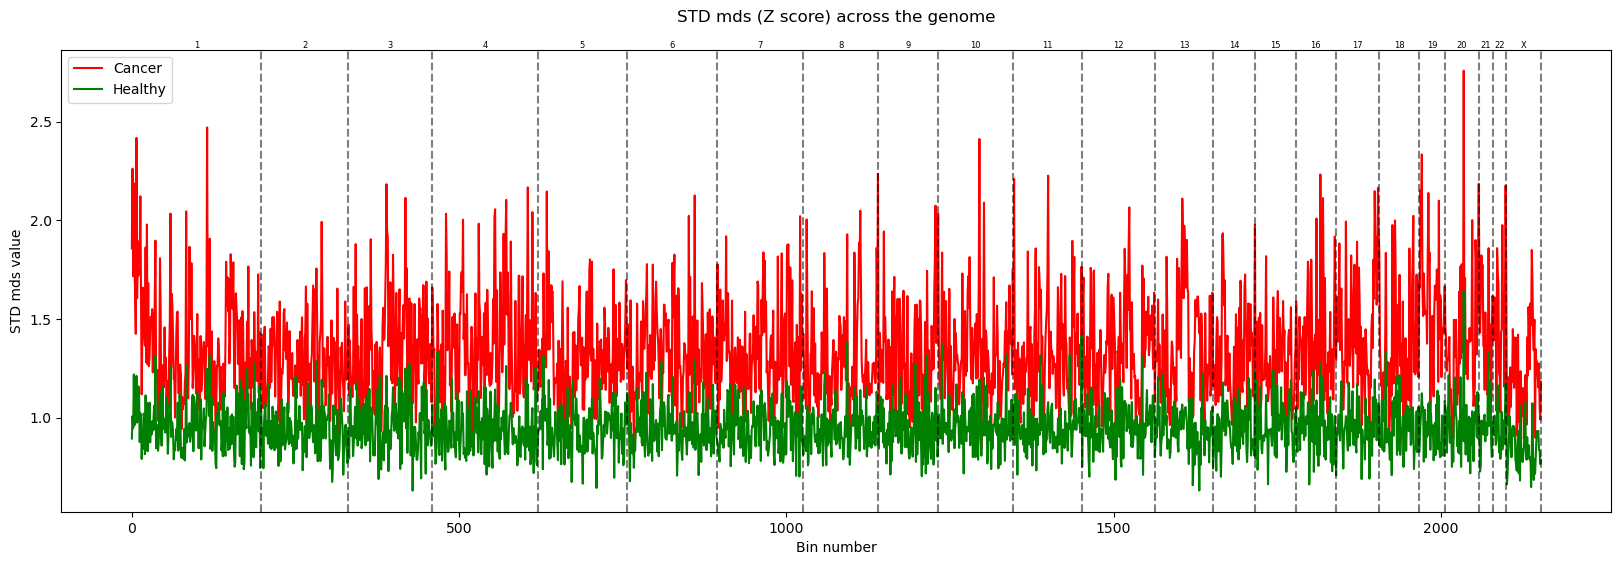

In [57]:
feat = "mds"  # fslr,mds
z = True  # Z score transform
met = "STD"  # STD, AVG
save = False

compare_cancer_healthy(feat, z, met, save)